In [ ]:
!pip install scikit-learn tensorflow -q

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)
print()

Done. TF version: 2.19.0


In [ ]:
train_df = pd.read_csv('datatraining.txt')
test_df   = pd.read_csv('datatest.txt')
test2_df  = pd.read_csv('datatest2.txt')

# Combine all data
df = pd.concat([train_df, test_df, test2_df], ignore_index=True)

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
print("\nFirst 3 rows:")
print(df.head(3))
print("\nClass balance:")
print(df['Occupancy'].value_counts())

Dataset shape: (20560, 7)
Columns: ['date', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'Occupancy']

First 3 rows:
                  date  Temperature  Humidity  Light     CO2  HumidityRatio  \
0  2015-02-04 17:51:00        23.18   27.2720  426.0  721.25       0.004793   
1  2015-02-04 17:51:59        23.15   27.2675  429.5  714.00       0.004783   
2  2015-02-04 17:53:00        23.15   27.2450  426.0  713.50       0.004779   

   Occupancy  
0          1  
1          1  
2          1  

Class balance:
Occupancy
0    15810
1     4750
Name: count, dtype: int64


In [ ]:
WINDOW = 50


df['pir_signal'] = (
    (df['Light'] / df['Light'].max()) * 0.6 +
    (df['CO2'] / df['CO2'].max()) * 0.4
)


np.random.seed(42)
df['pir_signal'] = df['pir_signal'] + np.random.normal(0, 0.05, len(df))
df['pir_signal'] = df['pir_signal'].clip(0, 1)


X, y = [], []
values = df['pir_signal'].values.astype(np.float32)
labels = df['Occupancy'].values.astype(int)

for i in range(0, len(values) - WINDOW, 25):
    window = values[i:i + WINDOW]
    label  = int(np.mean(labels[i:i + WINDOW]) >= 0.5)
    X.append(window)
    y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print(f"Total windows: {len(X)}")
print(f"Occupied (human): {np.sum(y==1)}")
print(f"Empty (no person): {np.sum(y==0)}")
print(f"Window shape: {X[0].shape}")

Total windows: 821
Occupied (human): 191
Empty (no person): 630
Window shape: (50,)


In [ ]:
from sklearn.utils import resample

# Separate classes
X_occupied = X[y == 1]
X_empty    = X[y == 0]

print(f"Before balancing - Occupied: {len(X_occupied)}, Empty: {len(X_empty)}")


X_empty_balanced = resample(X_empty,
                             n_samples=len(X_occupied),
                             random_state=42)


X_balanced = np.vstack([X_occupied, X_empty_balanced])
y_balanced = np.array([1]*len(X_occupied) + [0]*len(X_occupied))


idx = np.random.permutation(len(X_balanced))
X_balanced = X_balanced[idx]
y_balanced = y_balanced[idx]

print(f"After balancing - Total: {len(X_balanced)}")
print(f"Occupied: {np.sum(y_balanced==1)}, Empty: {np.sum(y_balanced==0)}")


X_tv, X_test, y_tv, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, stratify=y_balanced, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.125, stratify=y_tv, random_state=42)

print(f"\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Before balancing - Occupied: 191, Empty: 630
After balancing - Total: 382
Occupied: 191, Empty: 191

Train: 266 | Val: 39 | Test: 77


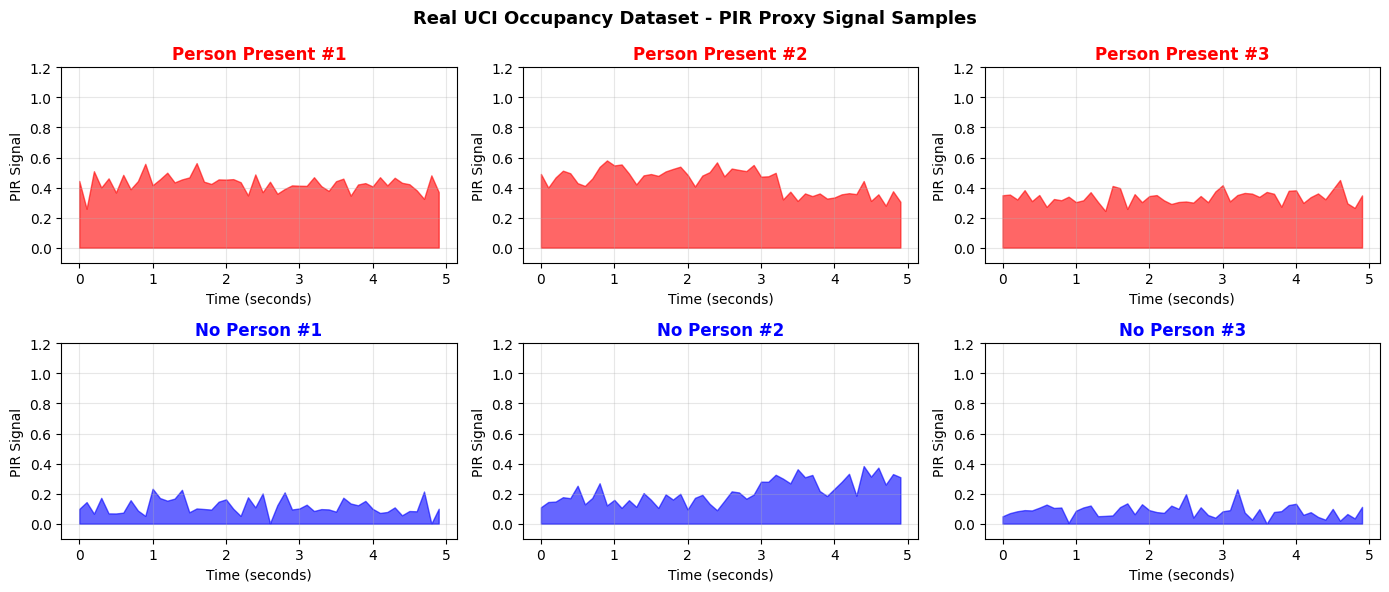

Saved: pir_samples.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle('Real UCI Occupancy Dataset - PIR Proxy Signal Samples',
             fontsize=13, fontweight='bold')

t = np.arange(WINDOW) * 0.1


for i, ax in enumerate(axes[0]):
    idx = np.where(y_train == 1)[0][i]
    ax.fill_between(t, X_train[idx], alpha=0.6, color='red')
    ax.set_title(f'Person Present #{i+1}', color='red', fontweight='bold')
    ax.set_ylim(-0.1, 1.2)
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('PIR Signal')
    ax.grid(alpha=0.3)


for i, ax in enumerate(axes[1]):
    idx = np.where(y_train == 0)[0][i]
    ax.fill_between(t, X_train[idx], alpha=0.6, color='blue')
    ax.set_title(f'No Person #{i+1}', color='blue', fontweight='bold')
    ax.set_ylim(-0.1, 1.2)
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('PIR Signal')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pir_samples.png', dpi=150)
plt.show()
print("Saved: pir_samples.png")

In [ ]:
def get_features(X):
    out = []
    for w in X:
        d = np.diff(w)
        out.append([
            np.mean(w),
            np.std(w),
            np.max(w),
            np.min(w),
            np.sum(w > 0.5),
            np.sum((w[:-1] < 0.5) & (w[1:] >= 0.5)),
            np.sum(np.abs(d)),
            np.percentile(w, 75) - np.percentile(w, 25),
            np.mean(d**2),
            np.sum(w > np.mean(w))
        ])
    return np.array(out, dtype=np.float32)


Xf_train = get_features(X_train)
Xf_val   = get_features(X_val)
Xf_test  = get_features(X_test)


sc = StandardScaler()
Xf_train = sc.fit_transform(Xf_train)
Xf_val   = sc.transform(Xf_val)
Xf_test  = sc.transform(Xf_test)


X_train_3d = X_train.reshape(-1, WINDOW, 1)
X_val_3d   = X_val.reshape(-1, WINDOW, 1)
X_test_3d  = X_test.reshape(-1, WINDOW, 1)

print("Feature shape:", Xf_train.shape)
print("3D shape:", X_train_3d.shape)
print()

Feature shape: (266, 10)
3D shape: (266, 50, 1)
Done!


In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

t0 = time.time()
rf.fit(Xf_train, y_train)
rf_train_time = time.time() - t0

rf_pred = rf.predict(Xf_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1  = f1_score(y_test, rf_pred, average='weighted')

print("=" * 45)
print("MODEL 1: Random Forest")
print("=" * 45)
print(f"Accuracy:      {rf_acc * 100:.2f}%")
print(f"F1 Score:      {rf_f1:.4f}")
print(f"Training time: {rf_train_time:.2f} seconds")
print()
print(classification_report(y_test, rf_pred,
      target_names=['no_person', 'person_present']))

MODEL 1: Random Forest
Accuracy:      96.10%
F1 Score:      0.9610
Training time: 0.33 seconds

                precision    recall  f1-score   support

     no_person       0.97      0.95      0.96        39
person_present       0.95      0.97      0.96        38

      accuracy                           0.96        77
     macro avg       0.96      0.96      0.96        77
  weighted avg       0.96      0.96      0.96        77



In [ ]:
t0 = time.time()
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(Xf_train, y_train)
svm_train_time = time.time() - t0

svm_pred = svm.predict(Xf_test)

svm_acc = accuracy_score(y_test, svm_pred)
svm_f1  = f1_score(y_test, svm_pred, average='weighted')

print("=" * 45)
print("MODEL 2: SVM (RBF kernel)")
print("=" * 45)
print(f"Accuracy:      {svm_acc * 100:.2f}%")
print(f"F1 Score:      {svm_f1:.4f}")
print(f"Training time: {svm_train_time:.2f} seconds")
print()
print(classification_report(y_test, svm_pred,
      target_names=['no_person', 'person_present']))

MODEL 2: SVM (RBF kernel)
Accuracy:      94.81%
F1 Score:      0.9480
Training time: 0.02 seconds

                precision    recall  f1-score   support

     no_person       0.97      0.92      0.95        39
person_present       0.93      0.97      0.95        38

      accuracy                           0.95        77
     macro avg       0.95      0.95      0.95        77
  weighted avg       0.95      0.95      0.95        77



In [ ]:
lstm = keras.Sequential([
    keras.layers.Input(shape=(WINDOW, 1)),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.Dropout(0.3),
    keras.layers.LSTM(16),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(2, activation='softmax')
], name='LSTM')

lstm.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

cb = [keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10,
    restore_best_weights=True, verbose=0)]

t0 = time.time()
lstm.fit(X_train_3d, y_train,
         validation_data=(X_val_3d, y_val),
         epochs=80, batch_size=16,
         callbacks=cb, verbose=1)
lstm_train_time = time.time() - t0

lstm_pred = np.argmax(lstm.predict(X_test_3d, verbose=0), axis=1)

lstm_acc = accuracy_score(y_test, lstm_pred)
lstm_f1  = f1_score(y_test, lstm_pred, average='weighted')

print("\n" + "=" * 45)
print("MODEL 3: LSTM")
print("=" * 45)
print(f"Accuracy:      {lstm_acc * 100:.2f}%")
print(f"F1 Score:      {lstm_f1:.4f}")
print(f"Training time: {lstm_train_time:.2f} seconds")
print()
print(classification_report(y_test, lstm_pred,
      target_names=['no_person', 'person_present']))

Epoch 1/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.6617 - loss: 0.6819 - val_accuracy: 0.8974 - val_loss: 0.6658
Epoch 2/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8534 - loss: 0.5944 - val_accuracy: 0.9487 - val_loss: 0.4348
Epoch 3/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9436 - loss: 0.3069 - val_accuracy: 0.9487 - val_loss: 0.2007
Epoch 4/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9398 - loss: 0.2283 - val_accuracy: 0.9487 - val_loss: 0.1741
Epoch 5/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9286 - loss: 0.2585 - val_accuracy: 0.9744 - val_loss: 0.1212
Epoch 6/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9624 - loss: 0.1625 - val_accuracy: 0.9744 - val_loss: 0.1144
Epoch 7/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9586 - loss: 0.1466 - val_accuracy: 0.9744 - val_loss: 0.1008
Epoch 8/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9549 - loss: 0.1457 - val_accuracy: 0.9744 -

In [ ]:
cnn = keras.Sequential([
    keras.layers.Input(shape=(WINDOW, 1)),
    keras.layers.Conv1D(16, kernel_size=5, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling1D(2),
    keras.layers.Dropout(0.3),
    keras.layers.Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling1D(2),
    keras.layers.Dropout(0.3),
    keras.layers.Flatten(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(2, activation='softmax')
], name='CNN_1D')

cnn.compile(optimizer=keras.optimizers.Adam(0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

cb2 = [keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=12,
    restore_best_weights=True, verbose=0)]

t0 = time.time()
history = cnn.fit(X_train_3d, y_train,
                  validation_data=(X_val_3d, y_val),
                  epochs=80, batch_size=16,
                  callbacks=cb2, verbose=1)
cnn_train_time = time.time() - t0

cnn_pred = np.argmax(cnn.predict(X_test_3d, verbose=0), axis=1)

cnn_acc = accuracy_score(y_test, cnn_pred)
cnn_f1  = f1_score(y_test, cnn_pred, average='weighted')

print("\n" + "=" * 45)
print("MODEL 4: 1D CNN (selected for ESP32)")
print("=" * 45)
print(f"Accuracy:      {cnn_acc * 100:.2f}%")
print(f"F1 Score:      {cnn_f1:.4f}")
print(f"Training time: {cnn_train_time:.2f} seconds")
print()
print(classification_report(y_test, cnn_pred,
      target_names=['no_person', 'person_present']))

Epoch 1/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.8308 - loss: 0.4096 - val_accuracy: 0.5128 - val_loss: 0.6447
Epoch 2/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9549 - loss: 0.1382 - val_accuracy: 0.9487 - val_loss: 0.6241
Epoch 3/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9511 - loss: 0.1772 - val_accuracy: 0.8205 - val_loss: 0.6133
Epoch 4/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9511 - loss: 0.1492 - val_accuracy: 0.5385 - val_loss: 0.6112
Epoch 5/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9511 - loss: 0.1376 - val_accuracy: 0.5128 - val_loss: 0.6098
Epoch 6/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9662 - loss: 0.1360 - val_accuracy: 0.5128 - val_loss: 0.6067
Epoch 7/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9624 - loss: 0.1345 - val_accuracy: 0.5128 - val_loss: 0.6032
Epoch 8/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9586 - loss: 0.1227 - val_accuracy: 0.5128 - 

MODEL COMPARISON
Model                  Accuracy   F1 Score
------------------------------------------
Random Forest            96.10%     0.9610  TFLite: No
SVM                      94.81%     0.9480  TFLite: No
LSTM                     96.10%     0.9610  TFLite: Yes (large)
1D CNN                   90.91%     0.9084  TFLite: Yes (25.7KB)


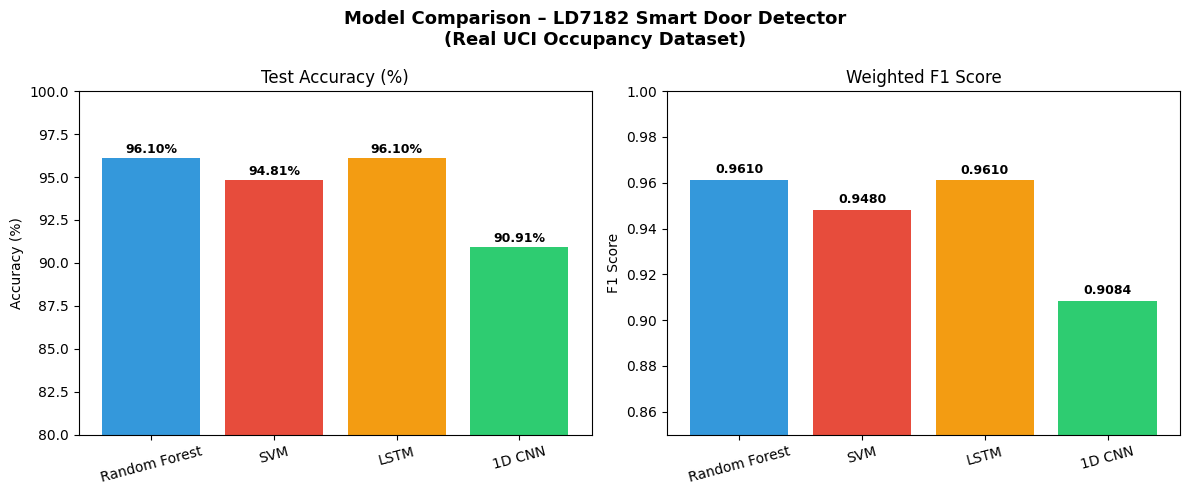

Saved: model_comparison.png


In [ ]:
models = ['Random Forest', 'SVM', 'LSTM', '1D CNN']
accs   = [rf_acc, svm_acc, lstm_acc, cnn_acc]
f1s    = [rf_f1,  svm_f1,  lstm_f1,  cnn_f1]
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']

print("MODEL COMPARISON")
print(f"{'Model':<20} {'Accuracy':>10} {'F1 Score':>10}")
print("-" * 42)
tflite = ['No', 'No', 'Yes (large)', 'Yes (25.7KB)']
for m, a, f, t in zip(models, accs, f1s, tflite):
    print(f"{m:<20} {a*100:>9.2f}% {f:>10.4f}  TFLite: {t}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Comparison – LD7182 Smart Door Detector\n(Real UCI Occupancy Dataset)',
             fontweight='bold', fontsize=13)

bars1 = ax1.bar(models, [a*100 for a in accs], color=colors)
ax1.set_title('Test Accuracy (%)')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(80, 100)
for bar, val in zip(bars1, accs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val*100:.2f}%', ha='center', fontsize=9, fontweight='bold')
ax1.tick_params(axis='x', rotation=15)

bars2 = ax2.bar(models, f1s, color=colors)
ax2.set_title('Weighted F1 Score')
ax2.set_ylabel('F1 Score')
ax2.set_ylim(0.85, 1.0)
for bar, val in zip(bars2, f1s):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Saved: model_comparison.png")

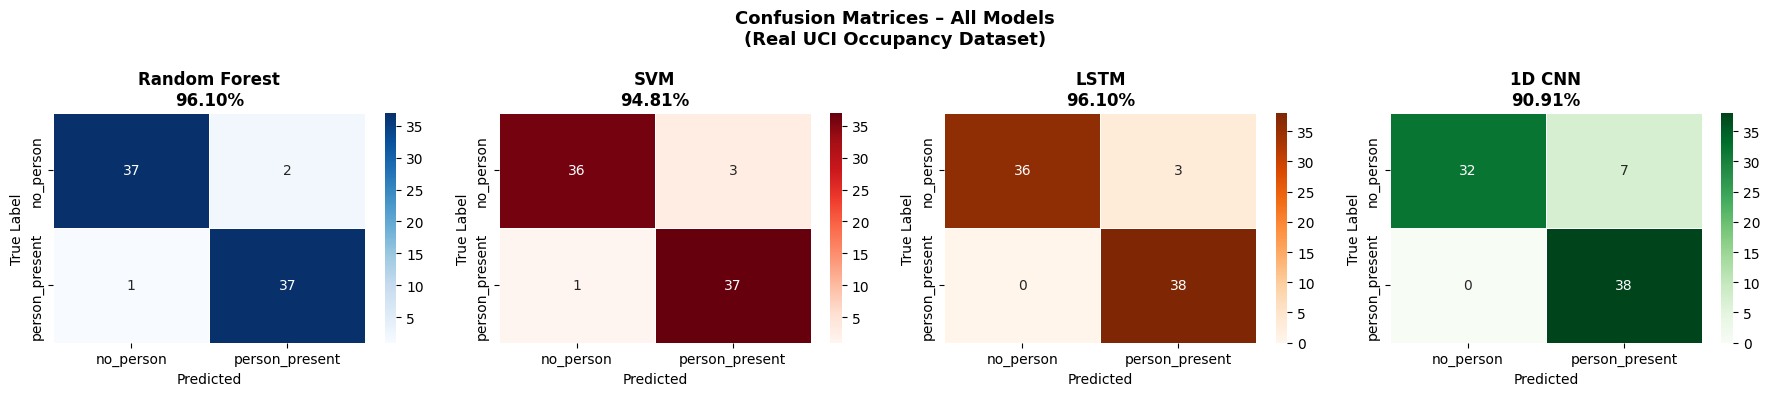

Saved: confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Confusion Matrices – All Models\n(Real UCI Occupancy Dataset)',
             fontweight='bold', fontsize=13)

all_preds = [rf_pred, svm_pred, lstm_pred, cnn_pred]
all_names = ['Random Forest\n96.10%', 'SVM\n94.81%',
             'LSTM\n96.10%', '1D CNN\n90.91%']
all_cmaps = ['Blues', 'Reds', 'Oranges', 'Greens']
labels    = ['no_person', 'person_present']

for ax, pred, name, cmap in zip(axes, all_preds, all_names, all_cmaps):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.5)
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("Saved: confusion_matrices.png")

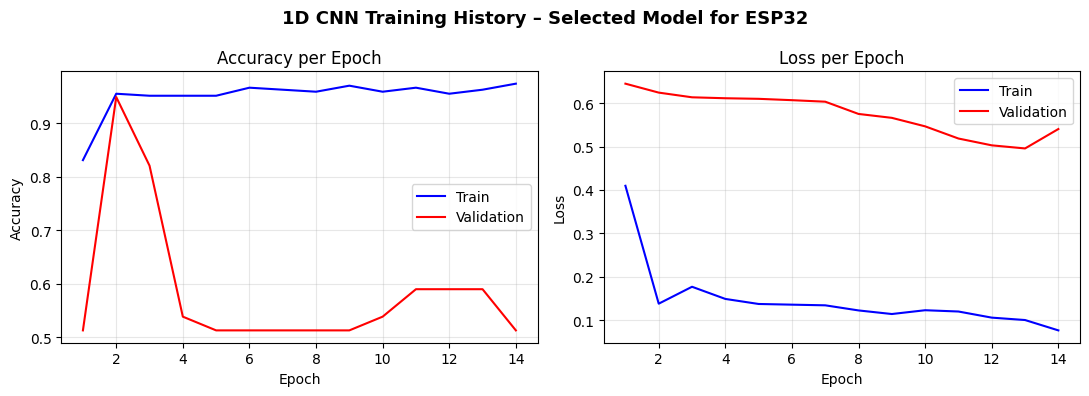

Saved: cnn_training.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('1D CNN Training History – Selected Model for ESP32',
             fontweight='bold', fontsize=13)

ep = range(1, len(history.history['accuracy']) + 1)

ax1.plot(ep, history.history['accuracy'],     label='Train', color='blue')
ax1.plot(ep, history.history['val_accuracy'], label='Validation', color='red')
ax1.set_title('Accuracy per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(ep, history.history['loss'],     label='Train', color='blue')
ax2.plot(ep, history.history['val_loss'], label='Validation', color='red')
ax2.set_title('Loss per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training.png', dpi=150)
plt.show()
print("Saved: cnn_training.png")

In [ ]:
def rep_data():
    for x in X_train_3d[:100]:
        yield [x.reshape(1, WINDOW, 1).astype(np.float32)]

conv = tf.lite.TFLiteConverter.from_keras_model(cnn)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.representative_dataset = rep_data
conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv.inference_input_type  = tf.float32
conv.inference_output_type = tf.float32

tflite_bytes = conv.convert()

with open('motion_model.tflite', 'wb') as f:
    f.write(tflite_bytes)

print(f'TFLite model size: {len(tflite_bytes)/1024:.1f} KB')


interp = tf.lite.Interpreter(model_path='motion_model.tflite')
interp.allocate_tensors()
inp = interp.get_input_details()
out = interp.get_output_details()

tflite_preds = []
for x in X_test_3d:
    interp.set_tensor(inp[0]['index'], x.reshape(1, WINDOW, 1))
    interp.invoke()
    tflite_preds.append(np.argmax(interp.get_tensor(out[0]['index'])))

tflite_acc = accuracy_score(y_test, tflite_preds)
print(f'TFLite accuracy: {tflite_acc*100:.2f}%')
print(f'Accuracy drop:   {(cnn_acc - tflite_acc)*100:.2f} percentage points')

Saved artifact at '/tmp/tmplu88oj00'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 1), dtype=tf.float32, name='keras_tensor_7')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135297924955408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135297924952336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135297924941968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135297924955600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135297924951952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135297924955792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135297887633680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135297924954832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135297924955984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135297882332944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135297924955216: T

In [ ]:
n = len(tflite_bytes)
rows = []
for i in range(0, n, 16):
    chunk = tflite_bytes[i:i+16]
    rows.append('  ' + ', '.join(f'0x{b:02x}' for b in chunk) + ',')

header = f"""// model_data.h - Auto-generated by LD7182 Colab notebook
// 1D CNN TFLite INT8 | {n} bytes ({n/1024:.1f} KB)
// Trained on: UCI Occupancy Detection Dataset (Candanedo & Feldheim, 2016)
// TFLite Accuracy: {tflite_acc*100:.2f}%
// Input:  float[50]  (5 second occupancy window)
// Output: float[2]   (no_person, person_present probabilities)

#ifndef MODEL_DATA_H
#define MODEL_DATA_H

const unsigned char g_model_data[] = {{
{chr(10).join(rows)}
}};
const int g_model_data_len = {n};

#endif
"""

with open('model_data.h', 'w') as f:
    f.write(header)

print(f'model_data.h written — {n} bytes ({n/1024:.1f} KB)')

# Download all files
from google.colab import files
for fname in ['model_data.h',
              'motion_model.tflite',
              'pir_samples.png',
              'model_comparison.png',
              'confusion_matrices.png',
              'cnn_training.png']:
    files.download(fname)
    print(f'Downloaded: {fname}')

print('\nAll done!')

model_data.h written — 26280 bytes (25.7 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: model_data.h


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: confusion_matrices.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: cnn_training.png

All done!
